## **VPLIV STOPNJE IZOBRAZBE MATERE IN STAROST NA PRVO ROJSTVO**

Priprava podatkov, barv za grafe in popravek podatkov, da ni napak.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

podatki = pd.read_csv('data/raw/csv/izobrazba_prvi_otrok.csv', sep=';', encoding='cp1250', skiprows=2)

# koordinacija brav
barve = {
    "olive": "#8CB369",
    "gold": "#F4E285",
    "brown": "#F4A259",
    "teal": "#5B8E7D",
    "brick": "#BC4B51"
}

podatki = podatki.replace("...", np.nan)

for col in podatki.columns[2:]:
    podatki[col] = pd.to_numeric(podatki[col], errors='coerce')

# popravi imena stolpcev
podatki.columns = [
    col if i < 2 else col[:4]
    for i, col in enumerate(podatki.columns)
]

Analiza izobrazbe - ali vpliva na povečano število rojstev? Glede na graf, kjub temu, da se rojstva pri skoraj vseh skupinah pada, se vseeno vidi, da imajo več otrok meter z višjo/visokošolsko izobrazbo. Kar pomeni, da se matere bolj in bolj odločajo za otroke kasneje v življenju, ko dokončajo šolanje.  

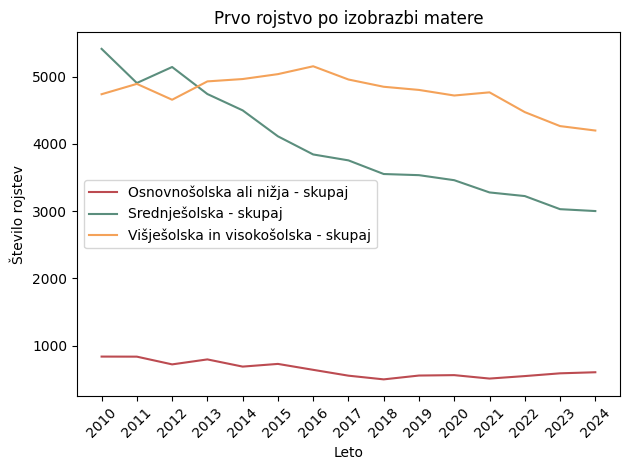

In [2]:
izobrazba = podatki[
    (podatki["STAROSTNE SKUPINE"] == "Starostne skupine - SKUPAJ") &
    (podatki["IZOBRAZBA MATERE"].isin([
        "Osnovnošolska ali nižja - skupaj",
        "Srednješolska - skupaj",
        "Višješolska in visokošolska - skupaj"
    ]))
]

izobrazba_t = izobrazba.iloc[:, 2:].T
izobrazba_t.columns = izobrazba["IZOBRAZBA MATERE"]

# Graf – izobrazba
plt.figure()
colors_list = [barve["brick"], barve["teal"], barve["brown"]]

for i, col in enumerate(izobrazba_t.columns):
    plt.plot(izobrazba_t.index, izobrazba_t[col], label=col, color=colors_list[i])

plt.xticks(rotation=45)
plt.legend()
plt.title("Prvo rojstvo po izobrazbi matere")
plt.xlabel("Leto")
plt.ylabel("Število rojstev")
plt.tight_layout()
plt.show()

Trend.


Trend:
Osnovnošolska ali nižja - skupaj: -21.42 na leto
Srednješolska - skupaj: -172.05 na leto
Višješolska in visokošolska - skupaj: -37.96 na leto


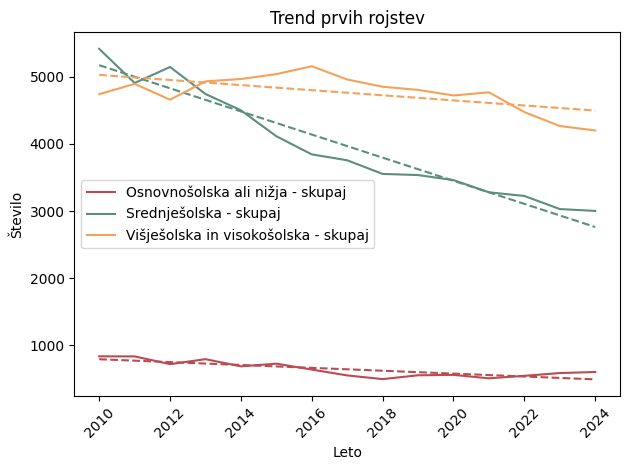

In [3]:
print("\nTrend:")

trend_results = {}

x = izobrazba_t.index.astype(int)

for col in izobrazba_t.columns:
    y = izobrazba_t[col].values
    
    slope, intercept = np.polyfit(x, y, 1)
    trend_results[col] = slope
    
    print(f"{col}: {slope:.2f} na leto")

# graf z regresijo
plt.figure()

for i, col in enumerate(izobrazba_t.columns):
    y = izobrazba_t[col].values
    slope, intercept = np.polyfit(x, y, 1)
    trend_line = slope * x + intercept

    plt.plot(x, y, label=col, color=colors_list[i])
    plt.plot(x, trend_line, linestyle='--', color=colors_list[i])

plt.xticks(rotation=45)
plt.legend()
plt.title("Trend prvih rojstev")
plt.xlabel("Leto")
plt.ylabel("Število")
plt.tight_layout()
plt.show()

Za prvega otroka se odločijo matere 25-29 let. Pod 20, 40-44, 45+ je redko, da imajo prvega otroka v tej starosti. 


Povprečje po starostnih skupinah:
STAROSTNE SKUPINE
Starostne skupine - SKUPAJ    9373.200000
25-29 let                     3720.866667
30-34 let                     2729.066667
20-24 let                     1589.000000
35-39 let                      961.333333
40-44 let                      192.666667
Pod 20 let                     166.666667
45+ let                         13.600000
dtype: float64


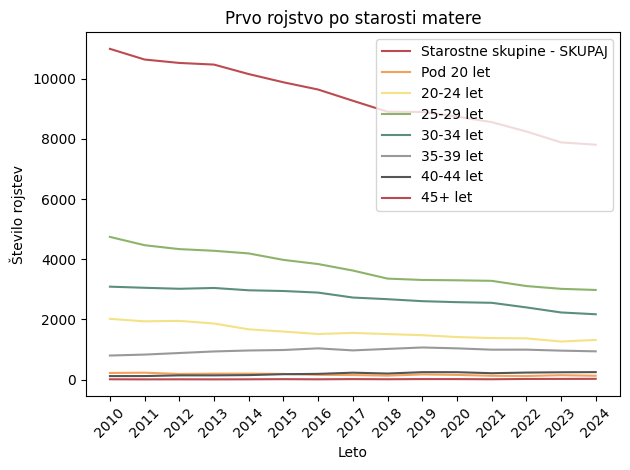

In [4]:
starost = podatki[podatki["IZOBRAZBA MATERE"] == "Izobrazba matere - SKUPAJ"]

starost_t = starost.iloc[:, 2:].T
starost_t.columns = starost["STAROSTNE SKUPINE"]

print("\nPovprečje po starostnih skupinah:")
print(starost_t.mean().sort_values(ascending=False))

plt.figure()
colors_starost = [
    barve["brick"],   # skupaj
    barve["brown"],   # pod 20
    barve["gold"],    # 20-24
    barve["olive"],   # 25-29
    barve["teal"],    # 30-34
    "#999999",        # 35-39
    "#555555"         # 40+
]

for i, col in enumerate(starost_t.columns):
    plt.plot(starost_t.index, starost_t[col], label=col, color=colors_starost[i % len(colors_starost)])

plt.xticks(rotation=45)
plt.legend()
plt.title("Prvo rojstvo po starosti matere")
plt.xlabel("Leto")
plt.ylabel("Število rojstev")
plt.tight_layout()
plt.show()

Prikaz grafa kako pada število prvorojencev iz leta v leto.

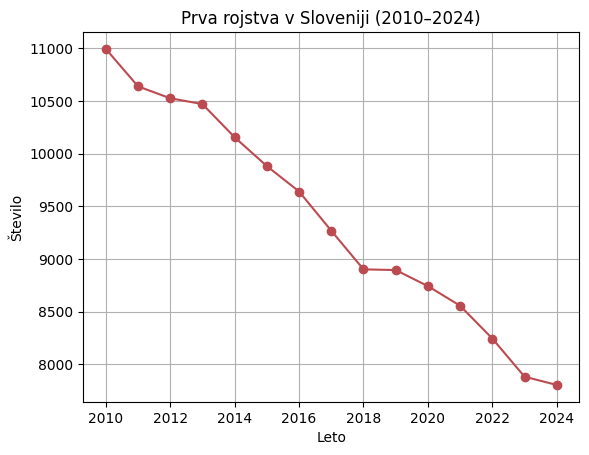

In [5]:
skupaj = podatki[
    (podatki["STAROSTNE SKUPINE"] == "Starostne skupine - SKUPAJ") &
    (podatki["IZOBRAZBA MATERE"] == "Izobrazba matere - SKUPAJ")
]

letni_trend = skupaj.iloc[0, 2:].reset_index()
letni_trend.columns = ['leto', 'stevilo']

# izvleci leto iz "2010 Prvo rojstvo"
letni_trend['leto'] = letni_trend['leto'].str.extract(r'(\d{4})').astype(int)

plt.figure()
plt.plot(
    letni_trend['leto'],
    letni_trend['stevilo'],
    marker='o',
    color=barve["brick"]
)

plt.title('Prva rojstva v Sloveniji (2010–2024)')
plt.xlabel('Leto')
plt.ylabel('Število')
plt.grid(True)
plt.show()